# Taller 1 — Notebook 03: Análisis, hipótesis y visualización

**MINE-4101: Ciencia de Datos Aplicada · Supervisión de contratación pública de bienes**

---

## Objetivo del notebook

Cubre los **Entregables 2 (Estrategia, 15%)** y **3 (Desarrollo, 40%)**. Sobre el dataset limpio
(`data/processed/secop_bienes_limpio.parquet`, generado en `02`) formulamos y contrastamos **hipótesis
explícitas** —pocas y ligadas a las palancas de focalización— sobre qué características *conocidas al firmar*
se asocian con las tres desviaciones de la ejecución, usando estadística inferencial y visualización
multivariada. Se reportan resultados **significativos y no significativos**.

> **Ejecutar después de** `01_entendimiento` y `02_limpieza`.


## 2. Estrategia de análisis (Entregable 2 — 15%)

**Objetivo analítico.** La pregunta de negocio no es descriptiva sino de decisión: *¿a qué contratos conviene
hacer seguimiento cercano desde la firma?* Por eso el análisis se organiza alrededor de las **palancas de
focalización** disponibles al momento de firmar (valor, modalidad, tipo de contrato, sector, orden de la
entidad, destino del gasto y tamaño del proveedor) y su relación con las tres desviaciones construidas en `02`
—`adicion_plazo`, `subejecucion`, `sin_liquidar`— que analizamos por separado porque responden a mecanismos
distintos.

**Estrategia y técnicas.** En lugar de un barrido exhaustivo de todos los cruces posibles, formulamos **cinco
hipótesis dirigidas**, cada una asociada a una palanca accionable y con una **dirección esperada** (incluida una
hipótesis *nula* de negocio). Para contrastarlas usamos: **U de Mann-Whitney** para el valor (numérico y muy
sesgado) frente a cada desviación; **χ² de independencia** con la **V de Cramér** como tamaño de efecto para los
atributos categóricos; y **mapas de calor** de la tasa de desviación por combinaciones de atributos para
detectar segmentos de alto riesgo. **Justificación:** dado que la muestra es muy grande (decenas de miles), casi
cualquier asociación resulta significativa, por lo que la decisión de qué criterios son útiles se basa en el
**tamaño de efecto**, no solo en el p-valor. El análisis se restringe al periodo comparable definido en `01`–`02`
(firma ≤ 2023) y, para las desviaciones que requieren cierre, a contratos con ciclo cerrado. La priorización
concreta de la supervisión se argumenta —de forma cualitativa y basada en estos resultados— en el informe
ejecutivo (Entregable 4).


## 3. Desarrollo de la estrategia (Entregable 3 — 40%)

### 3.0 Preparación: carga, bases analíticas y utilidades


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

RUTA_LIMPIO = '../data/processed/secop_bienes_limpio.parquet'
RUTA_FIGS = '../figs'
ALPHA = 0.05

d = pd.read_parquet(RUTA_LIMPIO)
print(f'Dataset limpio: {d.shape[0]:,} x {d.shape[1]}')

# Bases analíticas (comparabilidad de cohortes: firma <= 2023)
base_adic = d[d['periodo_analisis']].copy()                 # adición observable durante la ejecución
base_sub = d[d['subejecucion'].notna()].copy()              # ciclo cerrado & periodo & ejecución reportada
base_liq = d[d['sin_liquidar'].notna()].copy()              # ciclo cerrado & periodo
print(f'Base adición   (firma<=2023):            {len(base_adic):,}  | tasa {base_adic["adicion_plazo"].mean()*100:.1f}%')
print(f'Base subejecución (cerrado & reportado): {len(base_sub):,}  | tasa {base_sub["subejecucion"].mean()*100:.1f}%')
print(f'Base sin liquidar (cerrado):             {len(base_liq):,}  | tasa {base_liq["sin_liquidar"].mean()*100:.1f}%')


Dataset limpio: 196,391 x 61


Base adición   (firma<=2023):            121,644  | tasa 7.0%
Base subejecución (cerrado & reportado): 38,128  | tasa 7.9%
Base sin liquidar (cerrado):             68,351  | tasa 59.2%


In [2]:
# --- Utilidades de prueba de hipótesis ---
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum(); k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

def interp_v(v):
    return 'nulo' if v < 0.05 else 'pequeño' if v < 0.15 else 'moderado' if v < 0.25 else 'fuerte'

def test_categorica(df, flag, cat, min_n=200):
    '''χ² de independencia entre `cat` y `flag` + V de Cramér y tabla de tasas.'''
    sub = df[df[flag].notna()].copy()
    sub[flag] = sub[flag].astype(bool)
    ct = pd.crosstab(sub[cat], sub[flag])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    tasas = sub.groupby(cat)[flag].agg(tasa='mean', n='size')
    tasas = tasas[tasas['n'] >= min_n].sort_values('tasa', ascending=False)
    tasas['tasa'] = (tasas['tasa'] * 100).round(1)
    return {'p': p, 'V': v, 'sig': p < ALPHA, 'efecto': interp_v(v), 'tasas': tasas}

def test_valor(df, flag, col='valor_log'):
    '''Mann-Whitney del valor (log) entre contratos desviados y no desviados.'''
    sub = df[df[flag].notna() & df[col].notna()].copy()
    sub[flag] = sub[flag].astype(bool)
    g1 = sub.loc[sub[flag], col]; g0 = sub.loc[~sub[flag], col]
    u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    return {'p': p, 'sig': p < ALPHA, 'med_desv': 10**g1.median(), 'med_no': 10**g0.median(),
            'n_desv': len(g1), 'n_no': len(g0)}

print('Utilidades listas. α =', ALPHA)
print('Nota: con n grande el p-valor casi siempre es significativo; se prioriza la V de Cramér (tamaño de efecto).')


Utilidades listas. α = 0.05
Nota: con n grande el p-valor casi siempre es significativo; se prioriza la V de Cramér (tamaño de efecto).


### 3.1 Panorama de las tres desviaciones

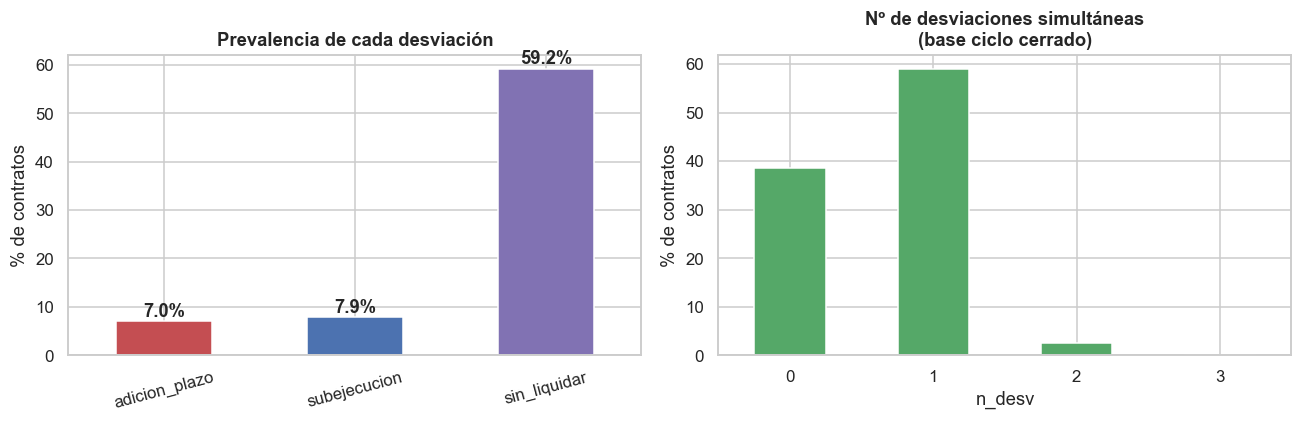

n_desv
0   38.600
1   59.000
2    2.400
3    0.000


In [3]:
# Prevalencia y solapamiento sobre la base con ciclo cerrado (donde las 3 banderas están definidas)
com = base_liq.copy()
com['f_adic'] = com['adicion_plazo'].astype(int)
com['f_sub'] = com['subejecucion'].fillna(False).astype(int)   # subejec puede ser NaN (facturado=0)
com['f_liq'] = com['sin_liquidar'].astype(int)
com['n_desv'] = com[['f_adic', 'f_sub', 'f_liq']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tasas_glob = pd.Series({
    'adicion_plazo': base_adic['adicion_plazo'].mean(),
    'subejecucion': base_sub['subejecucion'].mean(),
    'sin_liquidar': base_liq['sin_liquidar'].mean(),
}) * 100
tasas_glob.plot(kind='bar', ax=axes[0], color=['#C44E52', '#4C72B0', '#8172B3'])
axes[0].set_title('Prevalencia de cada desviación'); axes[0].set_ylabel('% de contratos'); axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(tasas_glob): axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

com['n_desv'].value_counts(normalize=True).sort_index().mul(100).plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Nº de desviaciones simultáneas\n(base ciclo cerrado)'); axes[1].set_ylabel('% de contratos'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_panorama.png', bbox_inches='tight'); plt.show()
print(com['n_desv'].value_counts(normalize=True).sort_index().mul(100).round(1).to_string())


Las tres desviaciones tienen prevalencias muy distintas: `sin_liquidar` es masiva (~59%), mientras
`adicion_plazo` y `subejecucion` rondan el 7–8%. La mayoría de contratos cerrados acumula **al menos una**
desviación (sobre todo la no-liquidación), pero la coincidencia de las tres es poco frecuente: conviene
tratarlas como señales **complementarias**, no como un único fenómeno.


### 3.2 Hipótesis 1 — El valor del contrato como señal de riesgo (no monotónica)

> **H1.** El valor del contrato es un criterio de focalización, pero **con dirección distinta según la
> desviación**: los contratos de **mayor valor** presentan más **adiciones de plazo** y más **subejecución**,
> mientras que los de **menor valor** se cierran más **sin liquidar**.
> *(H0 en cada caso: la distribución del valor es igual entre contratos desviados y no desviados — Mann-Whitney.)*


H1 — Mann-Whitney del valor (mediana COP) entre desviados y no desviados:
  adicion_plazo   : desviados=72,133,000  no=28,850,000  -> desviados tienen valor MAYOR  (p=0.0e+00, sig)


  subejecucion    : desviados=54,803,795  no=30,000,000  -> desviados tienen valor MAYOR  (p=7.4e-78, sig)
  sin_liquidar    : desviados=27,988,650  no=42,150,000  -> desviados tienen valor MENOR  (p=5.4e-251, sig)


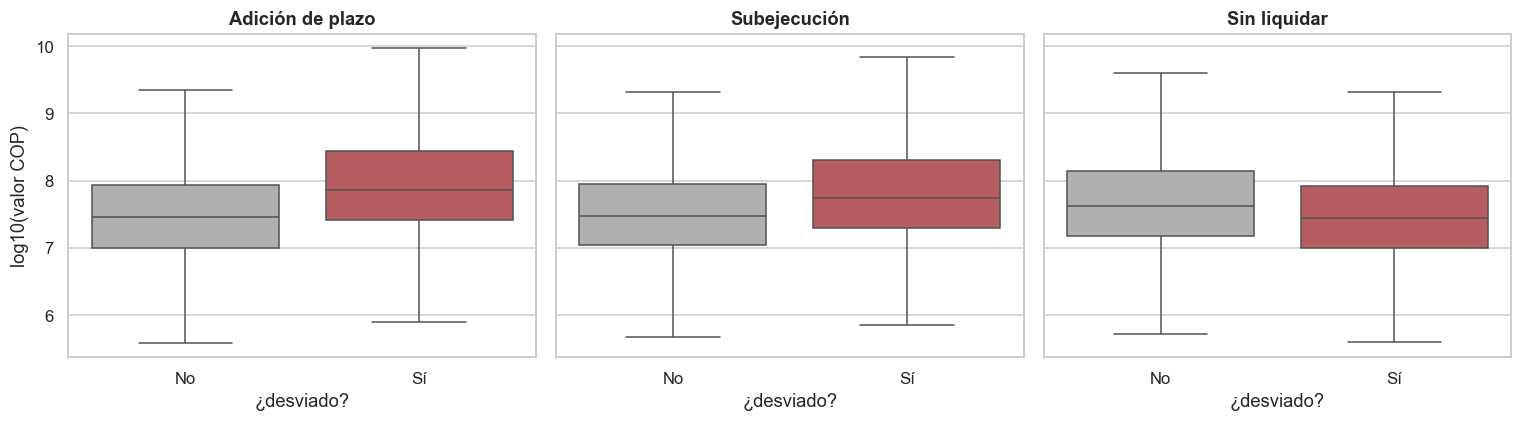

In [4]:
print('H1 — Mann-Whitney del valor (mediana COP) entre desviados y no desviados:')
res_valor = {}
for flag, base in [('adicion_plazo', base_adic), ('subejecucion', base_sub), ('sin_liquidar', base_liq)]:
    r = test_valor(base, flag); res_valor[flag] = r
    signo = 'MAYOR' if r['med_desv'] > r['med_no'] else 'MENOR'
    print(f'  {flag:16s}: desviados={r["med_desv"]:,.0f}  no={r["med_no"]:,.0f}  '
          f'-> desviados tienen valor {signo}  (p={r["p"]:.1e}, {"sig" if r["sig"] else "no sig"})')

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (flag, base, titulo) in zip(axes, [
        ('adicion_plazo', base_adic, 'Adición de plazo'),
        ('subejecucion', base_sub, 'Subejecución'),
        ('sin_liquidar', base_liq, 'Sin liquidar')]):
    sub = base[base['valor_log'].notna()].copy(); sub[flag] = sub[flag].astype(bool)
    sns.boxplot(data=sub, x=flag, y='valor_log', hue=flag, legend=False, ax=ax,
                showfliers=False, palette={False: '#B0B0B0', True: '#C44E52'})
    ax.set_title(titulo); ax.set_xlabel('¿desviado?'); ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Sí'])
axes[0].set_ylabel('log10(valor COP)')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h1_valor.png', bbox_inches='tight'); plt.show()


**H1 se confirma, incluida su parte no trivial:** las tres relaciones son significativas y el patrón es
**no monotónico**. A mayor valor, más adiciones y más subejecución (contratos grandes, más difíciles de
ejecutar en plazo y monto); pero la no-liquidación se concentra en contratos **pequeños** (valor mediano
menor), probablemente por menor exigencia de trámite de cierre. *Implicación de focalización:* el valor sirve
como criterio, pero el umbral debe leerse **en la dirección correcta** según la desviación que preocupe.


### 3.3 Hipótesis 2 — Modalidad de contratación y adiciones de plazo

> **H2.** Las modalidades más **competitivas y de mayor cuantía** (licitación pública, subasta inversa)
> presentan **mayor tasa de adiciones de plazo** que la mínima cuantía.
> *(H0: la tasa de adición es independiente de la modalidad — χ².)*


H2 — χ²: p=0.0e+00  V=0.117 (pequeño)  -> SIGNIFICATIVO


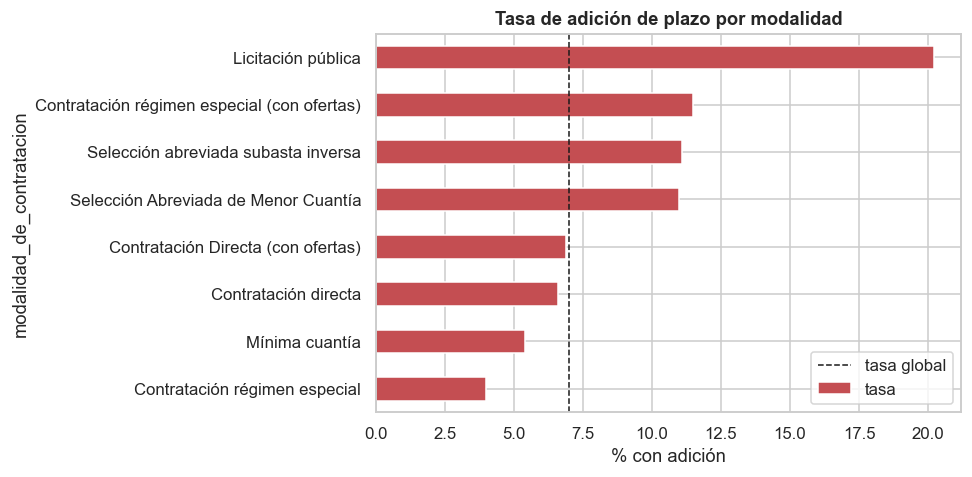

,tasa,n
modalidad_de_contratacion,,
Licitación pública,20.200,1615
Contratación régimen especial (con ofertas),11.500,3824
Selección abreviada subasta inversa,11.100,20449
Selección Abreviada de Menor Cuantía,11.000,5992
Contratación Directa (con ofertas),6.900,3421
Contratación directa,6.600,2700
Mínima cuantía,5.400,74032
Contratación régimen especial,4.000,9425


In [5]:
r = test_categorica(base_adic, 'adicion_plazo', 'modalidad_de_contratacion')
print(f'H2 — χ²: p={r["p"]:.1e}  V={r["V"]:.3f} ({r["efecto"]})  -> {"SIGNIFICATIVO" if r["sig"] else "no sig"}')

fig, ax = plt.subplots(figsize=(9, 4.5))
r['tasas']['tasa'].sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.axvline(base_adic['adicion_plazo'].mean()*100, color='k', ls='--', lw=1, label='tasa global')
ax.set_title('Tasa de adición de plazo por modalidad'); ax.set_xlabel('% con adición'); ax.legend()
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h2_modalidad.png', bbox_inches='tight'); plt.show()
r['tasas']


**H2 se confirma** (χ² significativo; V ≈ 0.12, el mayor efecto categórico para esta desviación).
**Licitación pública** presenta la tasa de adición más alta (~26%), seguida de las selecciones abreviadas y el
régimen especial con ofertas, todas muy por encima de **Mínima cuantía** (~7%), la modalidad más frecuente. Las
modalidades competitivas y de mayor cuantía concentran las adiciones de plazo.


### 3.4 Hipótesis 3 — Tipo de contrato y subejecución

> **H3.** Los contratos de **suministros** subejecutan el presupuesto **más** que los de **compraventa**.
> *(H0: la subejecución es independiente del tipo de contrato — χ².)* Se explora también el **destino del gasto**
> como palanca complementaria.


H3 — subejección vs tipo:  χ² p=0.0e+00  V=0.196 (moderado) -> SIGNIFICATIVO
     subejección vs destino: χ² p=1.5e-68  V=0.091 (pequeño) -> SIGNIFICATIVO


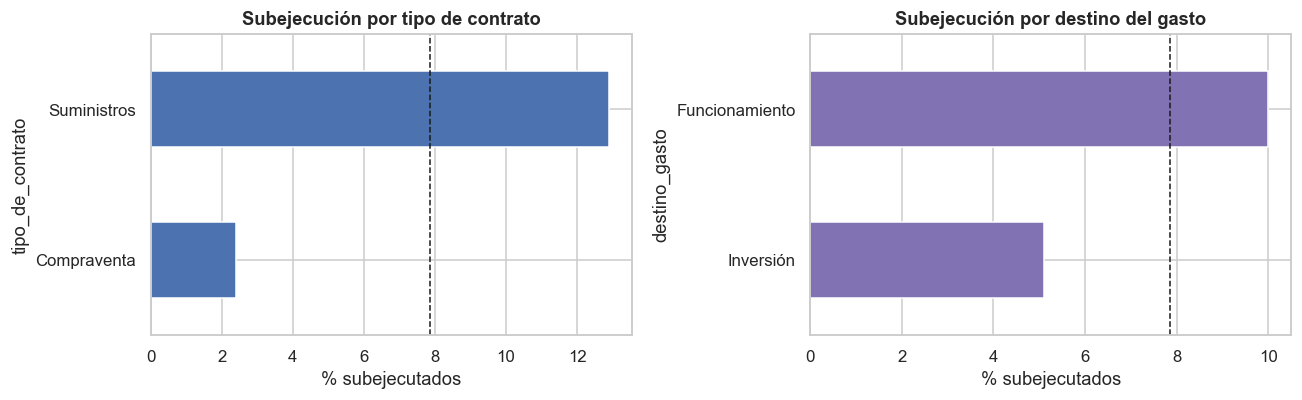

In [6]:
r = test_categorica(base_sub, 'subejecucion', 'tipo_de_contrato')
print(f'H3 — subejección vs tipo:  χ² p={r["p"]:.1e}  V={r["V"]:.3f} ({r["efecto"]}) -> {"SIGNIFICATIVO" if r["sig"] else "no sig"}')
rd = test_categorica(base_sub, 'subejecucion', 'destino_gasto')
print(f'     subejección vs destino: χ² p={rd["p"]:.1e}  V={rd["V"]:.3f} ({rd["efecto"]}) -> {"SIGNIFICATIVO" if rd["sig"] else "no sig"}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (cat, titulo, color) in zip(axes, [('tipo_de_contrato', 'tipo de contrato', '#4C72B0'),
                                           ('destino_gasto', 'destino del gasto', '#8172B3')]):
    t = test_categorica(base_sub, 'subejecucion', cat)['tasas']['tasa']
    t.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.axvline(base_sub['subejecucion'].mean()*100, color='k', ls='--', lw=1)
    ax.set_title(f'Subejecución por {titulo}'); ax.set_xlabel('% subejecutados')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h3_subejec.png', bbox_inches='tight'); plt.show()


**H3 se confirma con el mayor efecto categórico del análisis para subejecución** (V ≈ 0.20). Los
**Suministros** subejecutan mucho más (~13%) que la **Compraventa** (~2%): coherente con que el suministro es
entrega continua que puede no agotar el monto comprometido. Como palanca complementaria, **Funcionamiento**
subejecuta más (~10%) que **Inversión** (~5%).


### 3.5 Hipótesis 4 — Sector y orden de la entidad en la no-liquidación

> **H4.** La no-liquidación se concentra en **sectores específicos** (p. ej. Salud) y es **más severa en
> entidades territoriales** que en las nacionales.
> *(H0: la no-liquidación es independiente del sector / del orden — χ².)*


H4 — sin_liquidar vs sector: χ² p=0.0e+00  V=0.316 (fuerte) -> SIGNIFICATIVO
     sin_liquidar vs orden:  χ² p=3.7e-277  V=0.136 (pequeño) -> SIGNIFICATIVO


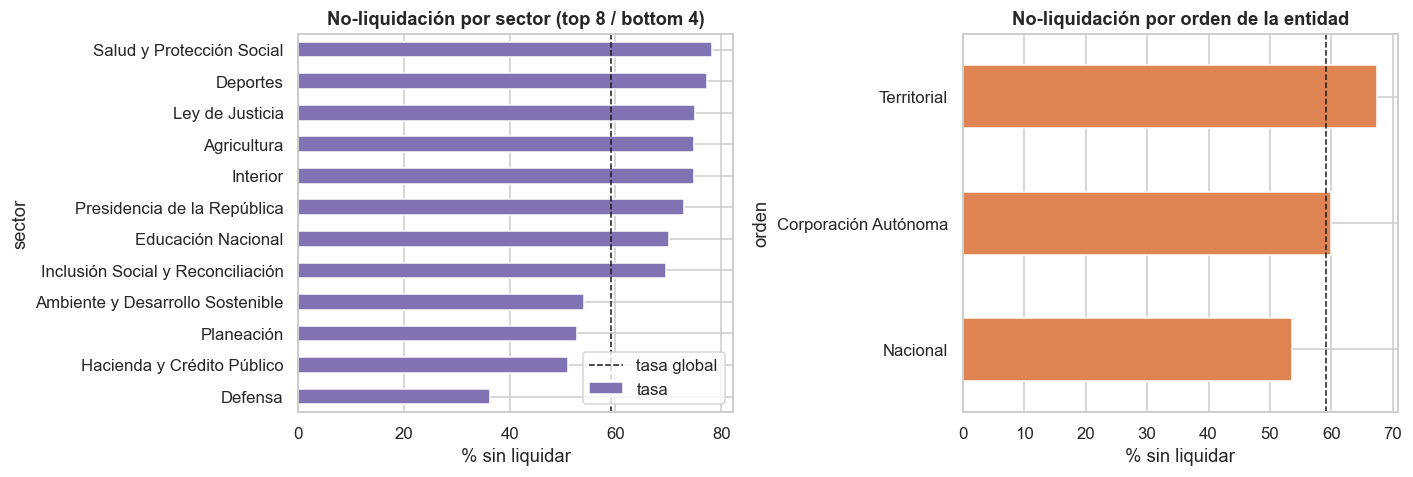

In [7]:
rs = test_categorica(base_liq, 'sin_liquidar', 'sector')
ro = test_categorica(base_liq, 'sin_liquidar', 'orden')
print(f'H4 — sin_liquidar vs sector: χ² p={rs["p"]:.1e}  V={rs["V"]:.3f} ({rs["efecto"]}) -> {"SIGNIFICATIVO" if rs["sig"] else "no sig"}')
print(f'     sin_liquidar vs orden:  χ² p={ro["p"]:.1e}  V={ro["V"]:.3f} ({ro["efecto"]}) -> {"SIGNIFICATIVO" if ro["sig"] else "no sig"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
top = pd.concat([rs['tasas'].head(8), rs['tasas'].tail(4)])
top['tasa'].sort_values().plot(kind='barh', ax=axes[0], color='#8172B3')
axes[0].axvline(base_liq['sin_liquidar'].mean()*100, color='k', ls='--', lw=1, label='tasa global')
axes[0].set_title('No-liquidación por sector (top 8 / bottom 4)'); axes[0].set_xlabel('% sin liquidar'); axes[0].legend()
ro['tasas']['tasa'].sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].axvline(base_liq['sin_liquidar'].mean()*100, color='k', ls='--', lw=1)
axes[1].set_title('No-liquidación por orden de la entidad'); axes[1].set_xlabel('% sin liquidar')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h4_sector_orden.png', bbox_inches='tight'); plt.show()


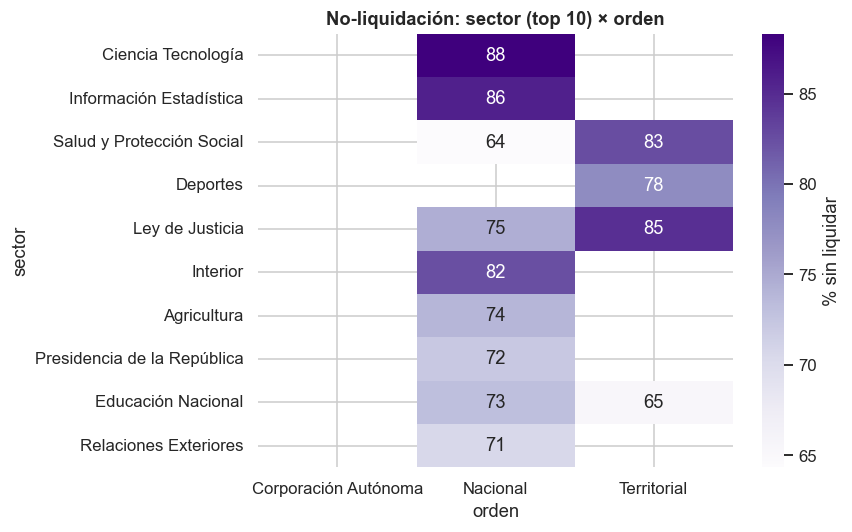

In [8]:
# Mapa de calor: tasa de no-liquidación por sector (top 10) × orden.
# También sirve para DESCONFUNDIR de forma descriptiva sector vs orden:
# comparar sectores DENTRO de cada columna de orden.
sub = base_liq.copy(); sub['sin_liquidar'] = sub['sin_liquidar'].astype(bool)
piv = sub.pivot_table(index='sector', columns='orden', values='sin_liquidar', aggfunc='mean') * 100
cnt = sub.pivot_table(index='sector', columns='orden', values='sin_liquidar', aggfunc='size')
piv = piv.mask(cnt < 100)
orden_sec = sub.groupby('sector')['sin_liquidar'].mean().sort_values(ascending=False).head(10).index
piv = piv.loc[[s for s in orden_sec if s in piv.index]]
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='Purples', ax=ax, cbar_kws={'label': '% sin liquidar'})
ax.set_title('No-liquidación: sector (top 10) × orden')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h4_heatmap.png', bbox_inches='tight'); plt.show()


**H4 se confirma y es la señal más fuerte y accionable de todo el análisis.** El **sector** tiene el mayor
tamaño de efecto (V ≈ 0.32, *fuerte*): sectores como **Salud y Protección Social** superan el ~78% sin liquidar,
frente a **Defensa** (~36%). El **orden** también es significativo: las entidades **territoriales** liquidan
menos (~67%) que las **nacionales** (~54%).

El mapa de calor permite una **desconfusión descriptiva**: al comparar sectores *dentro* de una misma columna
de orden, se ve que las diferencias por sector persisten, por lo que el sector aporta información **más allá**
del orden. *(Una cuantificación formal del efecto ajustado requeriría un modelo multivariable, fuera del alcance
de este análisis descriptivo — ver limitaciones en el informe.)*


### 3.6 Hipótesis 5 (nula) — El tamaño del proveedor (PyME) no discrimina

> **H5.** Ser **PyME** *no* es un criterio útil de focalización: **no** discrimina las desviaciones.
> *(H0: la tasa de desviación es independiente de `es_pyme` — χ². Aquí esperamos NO rechazar H0.)*


In [9]:
print('H5 — es_pyme vs cada desviación (χ²):')
for flag, base in [('adicion_plazo', base_adic), ('subejecucion', base_sub), ('sin_liquidar', base_liq)]:
    r = test_categorica(base, flag, 'es_pyme')
    print(f'  {flag:16s}: p={r["p"]:.2e}  V={r["V"]:.3f} ({r["efecto"]})  '
          f'-> {"significativo" if r["sig"] else "NO significativo"}')


H5 — es_pyme vs cada desviación (χ²):
  adicion_plazo   : p=4.80e-01  V=0.002 (nulo)  -> NO significativo


  subejecucion    : p=5.10e-68  V=0.089 (pequeño)  -> significativo
  sin_liquidar    : p=5.25e-02  V=0.007 (nulo)  -> NO significativo


**H5 se sostiene (resultado no significativo, reportado explícitamente).** El tamaño del proveedor no
discrimina las adiciones de plazo (p ≈ 0.48) ni la no-liquidación (p ≈ 0.05, borde), y aunque la subejecución
resulta estadísticamente significativa, su tamaño de efecto es **pequeño** (V ≈ 0.09). En términos prácticos,
`es_pyme` **no** es un buen criterio de focalización: no conviene priorizar la supervisión por el tamaño del
proveedor.


### 3.7 Síntesis de las hipótesis contrastadas

In [10]:
filas = [
    ['H1', 'Valor ~ desviación (dirección opuesta)', 'Mann-Whitney (×3)',
     'Confirmada', 'adic/subej: desv MAYOR valor; sin_liq: desv MENOR valor (los 3 p<0.001)'],
    ['H2', 'Adición ~ modalidad', 'χ²',
     'Confirmada', f'V={test_categorica(base_adic,"adicion_plazo","modalidad_de_contratacion")["V"]:.3f}; Licitación ~26% vs Mínima cuantía ~7%'],
    ['H3', 'Subejecución ~ tipo (y destino)', 'χ²',
     'Confirmada', f'V={test_categorica(base_sub,"subejecucion","tipo_de_contrato")["V"]:.3f}; Suministros ~13% vs Compraventa ~2%'],
    ['H4', 'No-liquidación ~ sector y orden', 'χ² (×2) + heatmap',
     'Confirmada', f'sector V={test_categorica(base_liq,"sin_liquidar","sector")["V"]:.3f} (fuerte); Territorial 67% vs Nacional 54%'],
    ['H5', 'Desviación ~ es_pyme (nula)', 'χ² (×3)',
     'No rechazada (nula sostenida)', 'adic p≈0.48; sin_liq p≈0.05; subej sig pero V≈0.09 (efecto pequeño)'],
]
resumen = pd.DataFrame(filas, columns=['H', 'Hipótesis', 'Prueba', 'Veredicto', 'Evidencia clave'])
resumen


,H,Hipótesis,Prueba,Veredicto,Evidencia clave
0,H1,Valor ~ desviación (dirección opuesta),Mann-Whitney (×3),Confirmada,adic/subej: desv MAYOR valor; sin_liq: desv ME...
1,H2,Adición ~ modalidad,χ²,Confirmada,V=0.117; Licitación ~26% vs Mínima cuantía ~7%
2,H3,Subejecución ~ tipo (y destino),χ²,Confirmada,V=0.196; Suministros ~13% vs Compraventa ~2%
3,H4,No-liquidación ~ sector y orden,χ² (×2) + heatmap,Confirmada,sector V=0.316 (fuerte); Territorial 67% vs Na...
4,H5,Desviación ~ es_pyme (nula),χ² (×3),No rechazada (nula sostenida),adic p≈0.48; sin_liq p≈0.05; subej sig pero V≈...


## 4. Insights principales

1. **El valor del contrato es una señal temprana con dirección dependiente de la desviación:** a **mayor** valor,
   más adiciones y subejecución; a **menor** valor, más no-liquidación. Un umbral de valor sirve para focalizar,
   pero debe leerse en la dirección correcta.
2. **La modalidad predice las adiciones de plazo:** Licitación pública y selecciones abreviadas adicionan mucho
   más que Mínima cuantía.
3. **El tipo de contrato es el mejor discriminador de la subejecución:** los **Suministros** subejecutan ~5×
   más que la Compraventa; **Funcionamiento** más que Inversión.
4. **El sector es el criterio más potente para la no-liquidación** (efecto fuerte), agravado en entidades
   **territoriales**; y la no-liquidación es un problema **masivo** (~59%).
5. **Resultado no significativo relevante:** el **tamaño del proveedor (PyME)** no discrimina las desviaciones —
   no es un criterio útil de focalización.

> **Advertencia metodológica.** Con esta muestra tan grande la significancia estadística no basta; las
> conclusiones se sostienen en el **tamaño de efecto** (V de Cramér, diferencias de mediana). El análisis es
> **bivariado/descriptivo**: no aísla efectos ajustados por confusión (p. ej. sector vs orden), lo cual se
> aborda de forma descriptiva con los mapas de calor y se declara como limitación en el informe.

**Siguiente paso:** informe ejecutivo (Entregable 4) con los criterios de focalización priorizados y las
limitaciones del análisis.
